# XGBoost — Entrenamiento Cloud (Kaggle Notebooks + GPU)

**Proyecto:** MECMT07 — Home Credit Default Risk  
**Plataforma:** Kaggle Notebooks con GPU P100 gratuita  
**Dataset fuente:** `mecmt07-features` (Dataset privado de Kaggle)

**Estrategia:**
- XGBoost maneja NaN nativamente → sin imputación
- `scale_pos_weight = N_neg / N_pos` para el desbalance de clases (≈11.39)
- Optuna (20 trials): objetivo = CV AUC − 0.5 · gap (penaliza overfitting)
- `early_stopping_rounds=50` dentro de `xgb.cv` para determinar `n_estimators` óptimo
- GPU P100 para acelerar el entrenamiento

**Outputs guardados en `/kaggle/working/`:**
- `xgboost_cloud_best.ubj` — modelo final (formato binario XGBoost)
- `xgboost_cloud_metadata.json` — hiperparámetros, AUC, feature_cols
- `optuna_trials.csv` — historial de todos los trials
- `feature_importance.png` — gráfico de importancia de variables

**Flujo post-entrenamiento:**
1. Descargar los 3 archivos `.ubj`, `.json`, `.csv` desde el Output tab
2. Descargar este notebook (File → Download Notebook) con todos los outputs preservados
3. Correr localmente `xgboost_cloud_predict.ipynb` para predecir y subir a Kaggle

In [1]:
# ─── Instalar dependencias ────────────────────────────────────────────────────
# Kaggle ya tiene preinstalados: xgboost, pandas, numpy, scikit-learn, pyarrow
# Solo necesitamos instalar optuna:
!pip install optuna --quiet
print('Dependencias listas.')

Dependencias listas.


In [2]:
# ─── Verificar GPU ────────────────────────────────────────────────────────────
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
if result.returncode == 0:
    print(result.stdout)
    USE_GPU = True
else:
    print('GPU no disponible — se usará CPU con todos los threads.')
    USE_GPU = False

print(f'USE_GPU = {USE_GPU}')

Wed Feb 25 02:53:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P0             26W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# ─── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
import json
import time
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print(f'XGBoost version : {xgb.__version__}')
print(f'Optuna  version : {optuna.__version__}')
print('Imports OK')

XGBoost version : 3.1.3
Optuna  version : 4.7.0
Imports OK


In [4]:
# ─── Configuración ────────────────────────────────────────────────────────────
# Ajustar DATA_DIR según entorno:
#   Kaggle Notebooks : Path('/kaggle/input/mecmt07-features')
#   Local            : Path('../../data/processed')
DATA_DIR  = Path('/kaggle/input/datasets/davidguzzi/mecmt07-features')
MODEL_DIR = Path('/kaggle/working')

N_TRIALS   = 20
N_FOLDS    = 5
EARLY_STOP = 50
MAX_ROUNDS = 1000
SEED       = 42

Path(MODEL_DIR).mkdir(parents=True, exist_ok=True)

matplotlib.rcParams.update({
    'figure.figsize': (9, 6),
    'font.size': 12,
    'axes.spines.top': False,
    'axes.spines.right': False
})

print('=' * 60)
print('CONFIGURACIÓN')
print(f'  DATA_DIR   : {DATA_DIR}')
print(f'  MODEL_DIR  : {MODEL_DIR}')
print(f'  N_TRIALS   : {N_TRIALS}')
print(f'  N_FOLDS    : {N_FOLDS}')
print(f'  EARLY_STOP : {EARLY_STOP}')
print(f'  MAX_ROUNDS : {MAX_ROUNDS}')
print(f'  SEED       : {SEED}')
print(f'  GPU        : {USE_GPU}')
print('=' * 60)

CONFIGURACIÓN
  DATA_DIR   : /kaggle/input/datasets/davidguzzi/mecmt07-features
  MODEL_DIR  : /kaggle/working
  N_TRIALS   : 20
  N_FOLDS    : 5
  EARLY_STOP : 50
  MAX_ROUNDS : 1000
  SEED       : 42
  GPU        : True


In [5]:
# ─── Cargar datos ─────────────────────────────────────────────────────────────
print('Cargando datos desde parquets...')
df      = pd.read_parquet(DATA_DIR / 'features_train.parquet')
df_test = pd.read_parquet(DATA_DIR / 'features_test.parquet')

feature_cols = [c for c in df.columns if c not in ('SK_ID_CURR', 'TARGET')]

X           = df[feature_cols].values
y           = df['TARGET'].values
X_test      = df_test[feature_cols].values
sk_ids_test = df_test['SK_ID_CURR'].values

# scale_pos_weight para desbalance de clases
n_neg, n_pos     = (y == 0).sum(), (y == 1).sum()
scale_pos_weight  = n_neg / n_pos

# DMatrix para xgb.cv
dtrain = xgb.DMatrix(X, label=y, feature_names=feature_cols)

print(f'  Train shape       : {X.shape}')
print(f'  Test  shape       : {X_test.shape}')
print(f'  Features          : {len(feature_cols)}')
print(f'  NaNs en X         : {np.isnan(X).sum():,}  (manejados nativamente por XGBoost)')
print(f'  TARGET=0 (paga)   : {n_neg:,}  ({100*n_neg/(n_neg+n_pos):.1f}%)')
print(f'  TARGET=1 (default): {n_pos:,}  ({100*n_pos/(n_neg+n_pos):.1f}%)')
print(f'  scale_pos_weight  : {scale_pos_weight:.2f}  (N_neg / N_pos)')

Cargando datos desde parquets...
  Train shape       : (307511, 30)
  Test  shape       : (48744, 30)
  Features          : 30
  NaNs en X         : 1,612,697  (manejados nativamente por XGBoost)
  TARGET=0 (paga)   : 282,686  (91.9%)
  TARGET=1 (default): 24,825  (8.1%)
  scale_pos_weight  : 11.39  (N_neg / N_pos)


In [6]:
# ─── Funciones auxiliares ─────────────────────────────────────────────────────
def compute_metrics(y_true, y_prob, threshold=0.5, label='Model'):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    auc  = roc_auc_score(y_true, y_prob)
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    return dict(Model=label, AUC=round(auc,4),
                N=len(y_true), P=int(y_pred.sum()),
                TP=int(tp), TN=int(tn), FP=int(fp), FN=int(fn),
                Recall=round(rec,4), Precision=round(prec,4), F1=round(f1,4))

print('Funciones auxiliares definidas.')

Funciones auxiliares definidas.


## 1. Optuna — Búsqueda de Hiperparámetros

**Función objetivo** (réplica del R script con `xgb.cv` + `early_stopping_rounds`):
$$\text{objetivo} = \text{AUC}_{\text{test-cv}} - 0.5 \cdot \max(0,\ \text{AUC}_{\text{train-cv}} - \text{AUC}_{\text{test-cv}})$$

El número óptimo de rondas de boosting se determina por early stopping dentro del `xgb.cv`.

In [7]:
# ─── Función objetivo de Optuna ───────────────────────────────────────────────
best_n_rounds_per_trial = {}   # guarda las rondas óptimas de cada trial

def objective_xgb(trial):
    params = {
        'max_depth'        : trial.suggest_int('max_depth', 2, 8),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'gamma'            : trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        # Fijos
        'objective'        : 'binary:logistic',
        'eval_metric'      : 'auc',
        'scale_pos_weight' : scale_pos_weight,
        'tree_method'      : 'hist',
        'device'           : 'cuda' if USE_GPU else 'cpu',
        'nthread'          : -1,
        'seed'             : SEED,
        'verbosity'        : 0,
    }

    # xgb.cv — idéntico al R script (xgb.cv + early_stopping_rounds)
    cv_results = xgb.cv(
        params                = params,
        dtrain                = dtrain,
        num_boost_round       = MAX_ROUNDS,
        nfold                 = N_FOLDS,
        stratified            = True,
        early_stopping_rounds = EARLY_STOP,
        metrics               = 'auc',
        seed                  = SEED,
        as_pandas             = True,
        verbose_eval          = False,
    )

    best_round = cv_results['test-auc-mean'].idxmax()
    cv_auc     = cv_results['test-auc-mean'].iloc[best_round]
    train_auc  = cv_results['train-auc-mean'].iloc[best_round]

    best_n_rounds_per_trial[trial.number] = best_round + 1

    gap = max(0.0, train_auc - cv_auc)
    return cv_auc - 0.5 * gap

print('Función objetivo definida.')

Función objetivo definida.


In [8]:
# ─── Optuna study — 20 trials ─────────────────────────────────────────────────
# n_jobs=1: cada trial usa todos los threads de GPU/CPU (no se puede paralelizar
#           entre trials en GPU; en CPU ya usa nthread=-1 internamente)

def _optuna_callback(study, trial):
    n      = best_n_rounds_per_trial.get(trial.number, '?')
    marker = ' ◀ best' if trial.number == study.best_trial.number else ''
    print(f'  Trial {trial.number + 1:>2}/{N_TRIALS} │ '
          f'obj={trial.value:.5f}  '
          f'rounds={str(n):>4}  │  '
          f'best={study.best_value:.5f}{marker}')

print('=' * 65)
print(f'Lanzando Optuna — {N_TRIALS} trials')
print(f'Folds CV: {N_FOLDS}  |  Early stopping: {EARLY_STOP} rounds')
print(f'Device: {"CUDA (GPU)" if USE_GPU else "CPU"}')
print('=' * 65)

study_xgb = optuna.create_study(
    direction = 'maximize',
    sampler   = optuna.samplers.TPESampler(seed=SEED)
)
study_xgb.optimize(
    objective_xgb,
    n_trials            = N_TRIALS,
    n_jobs              = 1,
    show_progress_bar   = False,
    callbacks           = [_optuna_callback]
)

best_n_rounds = best_n_rounds_per_trial[study_xgb.best_trial.number]

print('=' * 65)
print(f'Búsqueda finalizada.')
print(f'  Mejor CV AUC (obj penalizado) : {study_xgb.best_value:.5f}')
print(f'  n_estimators óptimos          : {best_n_rounds}')
print(f'  Mejores hiperparámetros:')
for k, v in study_xgb.best_params.items():
    print(f'    {k:<22}: {v}')
print('=' * 65)

# Guardar historial de trials
trial_df = study_xgb.trials_dataframe()
trial_df.to_csv(MODEL_DIR / 'optuna_trials.csv', index=False)
print(f'\nHistorial de trials guardado: {MODEL_DIR / "optuna_trials.csv"}')

Lanzando Optuna — 20 trials
Folds CV: 5  |  Early stopping: 50 rounds
Device: CUDA (GPU)
  Trial  1/20 │ obj=0.75205  rounds= 119  │  best=0.75205 ◀ best
  Trial  2/20 │ obj=0.74330  rounds=  94  │  best=0.75205
  Trial  3/20 │ obj=0.75438  rounds= 597  │  best=0.75438 ◀ best
  Trial  4/20 │ obj=0.74545  rounds= 135  │  best=0.75438
  Trial  5/20 │ obj=0.76318  rounds= 562  │  best=0.76318 ◀ best
  Trial  6/20 │ obj=0.76824  rounds= 998  │  best=0.76824 ◀ best
  Trial  7/20 │ obj=0.75183  rounds=1000  │  best=0.76824
  Trial  8/20 │ obj=0.76513  rounds=1000  │  best=0.76824
  Trial  9/20 │ obj=0.75917  rounds= 968  │  best=0.76824
  Trial 10/20 │ obj=0.76424  rounds= 780  │  best=0.76824
  Trial 11/20 │ obj=0.71698  rounds=1000  │  best=0.76824
  Trial 12/20 │ obj=0.76737  rounds=1000  │  best=0.76824
  Trial 13/20 │ obj=0.76603  rounds=1000  │  best=0.76824
  Trial 14/20 │ obj=0.76516  rounds= 999  │  best=0.76824
  Trial 15/20 │ obj=0.72830  rounds= 326  │  best=0.76824
  Trial 16/20

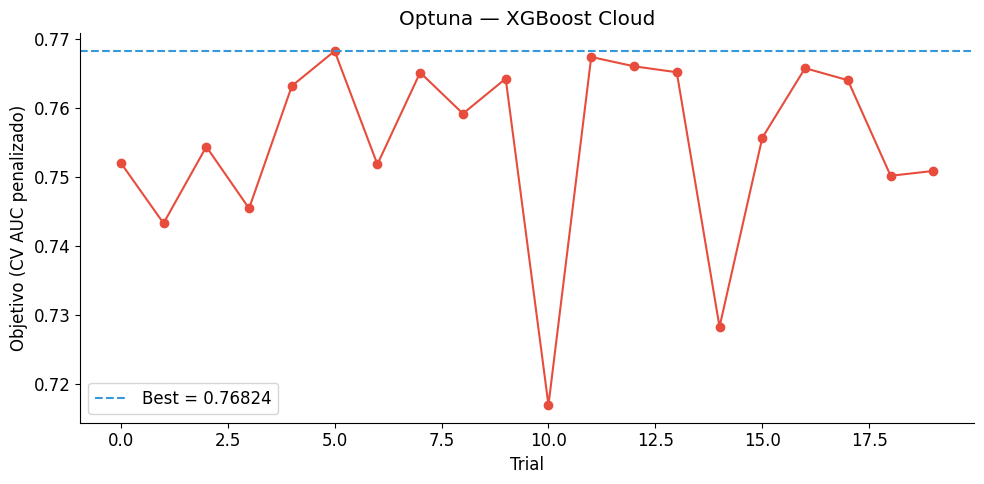

Gráfico guardado: /kaggle/working/optuna_history.png


In [9]:
# ─── Historial de Optuna — gráfico ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(trial_df['number'], trial_df['value'], 'o-', color='#e74c3c', ms=6)
ax.axhline(study_xgb.best_value, color='#3498db', ls='--',
           label=f'Best = {study_xgb.best_value:.5f}')
ax.set_xlabel('Trial')
ax.set_ylabel('Objetivo (CV AUC penalizado)')
ax.set_title('Optuna — XGBoost Cloud')
ax.legend()
plt.tight_layout()
plt.savefig(MODEL_DIR / 'optuna_history.png', dpi=120)
plt.show()
print(f'Gráfico guardado: {MODEL_DIR / "optuna_history.png"}')

## 2. Modelo Final — Refit en Train Completo

In [10]:
# ─── Entrenar modelo final ────────────────────────────────────────────────────
best_p = study_xgb.best_params

params_final = {
    'max_depth'        : best_p['max_depth'],
    'learning_rate'    : best_p['learning_rate'],
    'subsample'        : best_p['subsample'],
    'colsample_bytree' : best_p['colsample_bytree'],
    'min_child_weight' : best_p['min_child_weight'],
    'gamma'            : best_p['gamma'],
    'reg_alpha'        : best_p['reg_alpha'],
    'reg_lambda'       : best_p['reg_lambda'],
    'objective'        : 'binary:logistic',
    'eval_metric'      : 'auc',
    'scale_pos_weight' : scale_pos_weight,
    'tree_method'      : 'hist',
    'device'           : 'cuda' if USE_GPU else 'cpu',
    'nthread'          : -1,
    'seed'             : SEED,
    'verbosity'        : 0,
}

class ProgressCallback(xgb.callback.TrainingCallback):
    """Imprime progreso con porcentaje, AUC y ETA."""
    def __init__(self, total, interval=50):
        self.total    = total
        self.interval = interval
        self._t0      = None

    def before_training(self, model):
        self._t0 = time.time()
        return model

    def after_iteration(self, model, epoch, evals_log):
        last   = epoch == self.total - 1
        report = (epoch == 0) or ((epoch + 1) % self.interval == 0) or last
        if report:
            auc     = evals_log['train']['auc'][-1]
            elapsed = time.time() - self._t0
            eta     = elapsed / (epoch + 1) * (self.total - epoch - 1)
            pct     = (epoch + 1) / self.total * 100
            tag     = ' ✓' if last else ''
            print(f'  [{epoch + 1:>{len(str(self.total))}}/{self.total}]'
                  f'  {pct:5.1f}%'
                  f'  train-auc={auc:.5f}'
                  f'  elapsed={elapsed:5.0f}s'
                  f'  ETA={eta:4.0f}s{tag}')
        return False

print('=' * 65)
print(f'Entrenando modelo final en train completo...')
print(f'  Rondas de boosting : {best_n_rounds}')
print(f'  Device             : {"CUDA (GPU)" if USE_GPU else "CPU"}')
print('=' * 65)

evals_result = {}
xgb_final = xgb.train(
    params          = params_final,
    dtrain          = dtrain,
    num_boost_round = best_n_rounds,
    evals           = [(dtrain, 'train')],
    evals_result    = evals_result,
    verbose_eval    = False,
    callbacks       = [ProgressCallback(best_n_rounds, interval=50)],
)
print('=' * 65)
print('Modelo final entrenado ✓')

Entrenando modelo final en train completo...
  Rondas de boosting : 998
  Device             : CUDA (GPU)
  [  1/998]    0.1%  train-auc=0.66617  elapsed=    0s  ETA=  55s
  [ 50/998]    5.0%  train-auc=0.73664  elapsed=    0s  ETA=   3s
  [100/998]   10.0%  train-auc=0.75306  elapsed=    0s  ETA=   3s
  [150/998]   15.0%  train-auc=0.76121  elapsed=    0s  ETA=   2s
  [200/998]   20.0%  train-auc=0.76595  elapsed=    1s  ETA=   2s
  [250/998]   25.1%  train-auc=0.76924  elapsed=    1s  ETA=   2s
  [300/998]   30.1%  train-auc=0.77168  elapsed=    1s  ETA=   2s
  [350/998]   35.1%  train-auc=0.77330  elapsed=    1s  ETA=   2s
  [400/998]   40.1%  train-auc=0.77497  elapsed=    1s  ETA=   1s
  [450/998]   45.1%  train-auc=0.77627  elapsed=    1s  ETA=   1s
  [500/998]   50.1%  train-auc=0.77740  elapsed=    1s  ETA=   1s
  [550/998]   55.1%  train-auc=0.77847  elapsed=    1s  ETA=   1s
  [600/998]   60.1%  train-auc=0.77956  elapsed=    1s  ETA=   1s
  [650/998]   65.1%  train-auc=0.780

## 3. Métricas sobre Train Completo

In [11]:
# ─── Métricas finales ─────────────────────────────────────────────────────────
y_prob_train = xgb_final.predict(dtrain)
metrics      = compute_metrics(y, y_prob_train, threshold=0.5, label='XGBoost Cloud')
metrics['CV_AUC']   = round(study_xgb.best_value, 5)
metrics['n_rounds'] = best_n_rounds

print('=' * 65)
print('XGBOOST CLOUD — MÉTRICAS FINALES')
print('=' * 65)
print(f'  Train AUC       : {metrics["AUC"]}')
print(f'  CV AUC (Optuna) : {metrics["CV_AUC"]}  (obj penalizado por gap)')
print(f'  Gap Train - CV  : {metrics["AUC"] - metrics["CV_AUC"]:.5f}')
print(f'  n_rounds        : {metrics["n_rounds"]}')
print(f'  Recall          : {metrics["Recall"]}')
print(f'  Precision       : {metrics["Precision"]}')
print(f'  F1              : {metrics["F1"]}')
print(f'  TP/TN/FP/FN     : {metrics["TP"]} / {metrics["TN"]} / {metrics["FP"]} / {metrics["FN"]}')
print('=' * 65)

display(pd.DataFrame([metrics]).set_index('Model'))

XGBOOST CLOUD — MÉTRICAS FINALES
  Train AUC       : 0.7854
  CV AUC (Optuna) : 0.76824  (obj penalizado por gap)
  Gap Train - CV  : 0.01716
  n_rounds        : 998
  Recall          : 0.709
  Precision       : 0.1804
  F1              : 0.2876
  TP/TN/FP/FN     : 17602 / 202698 / 79988 / 7223


,AUC,N,P,TP,TN,FP,FN,Recall,Precision,F1,CV_AUC,n_rounds
Model,,,,,,,,,,,,
XGBoost Cloud,0.7854,307511,97590,17602,202698,79988,7223,0.709,0.1804,0.2876,0.76824,998


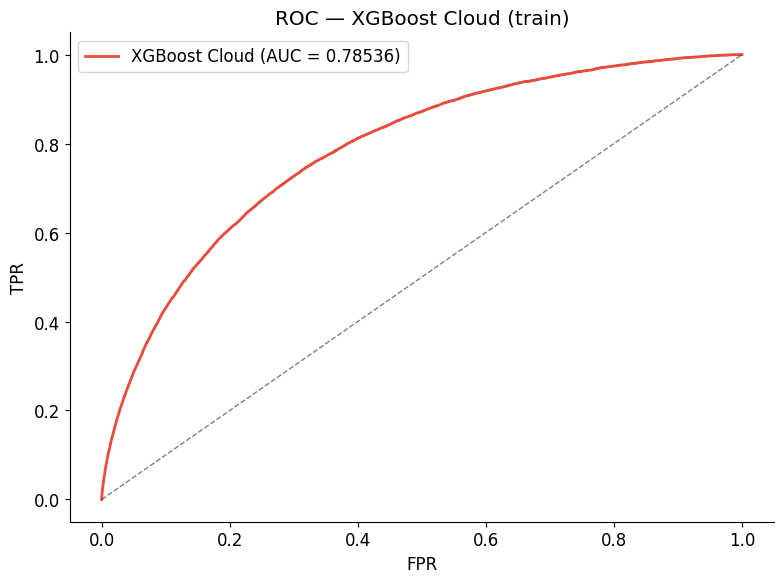

Curva ROC guardada: /kaggle/working/roc_curve.png


In [12]:
# ─── Curva ROC ────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y, y_prob_train)
auc_val      = roc_auc_score(y, y_prob_train)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'XGBoost Cloud (AUC = {auc_val:.5f})')
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — XGBoost Cloud (train)')
ax.legend()
plt.tight_layout()
plt.savefig(MODEL_DIR / 'roc_curve.png', dpi=120)
plt.show()
print(f'Curva ROC guardada: {MODEL_DIR / "roc_curve.png"}')

## 4. Learning Curve (Train AUC vs Ronda)

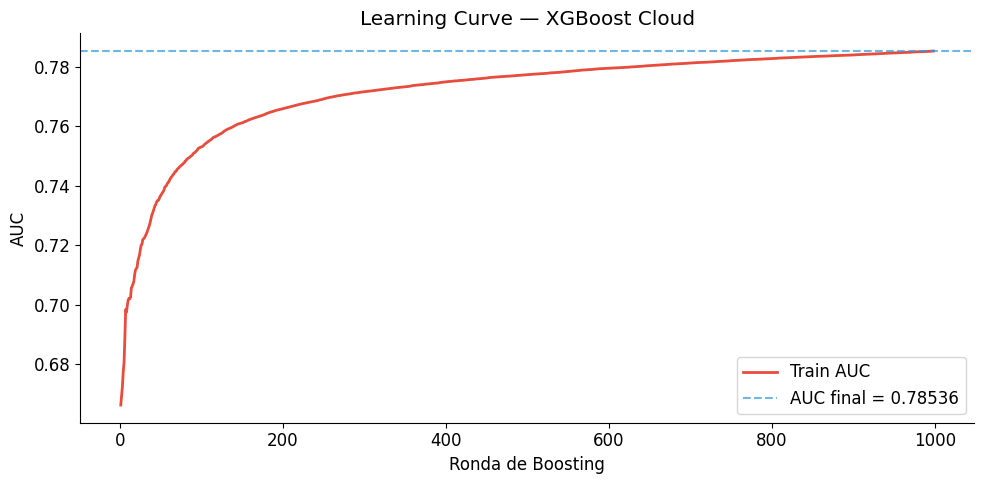

Learning curve guardada: /kaggle/working/learning_curve.png


In [13]:
# ─── Learning curve ───────────────────────────────────────────────────────────
train_auc_history = evals_result['train']['auc']
rounds            = np.arange(1, len(train_auc_history) + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(rounds, train_auc_history, color='#e74c3c', lw=2, label='Train AUC')
ax.axhline(train_auc_history[-1], color='#3498db', ls='--', alpha=0.7,
           label=f'AUC final = {train_auc_history[-1]:.5f}')
ax.set_xlabel('Ronda de Boosting')
ax.set_ylabel('AUC')
ax.set_title('Learning Curve — XGBoost Cloud')
ax.legend()
plt.tight_layout()
plt.savefig(MODEL_DIR / 'learning_curve.png', dpi=120)
plt.show()
print(f'Learning curve guardada: {MODEL_DIR / "learning_curve.png"}')

## 5. Importancia de Variables

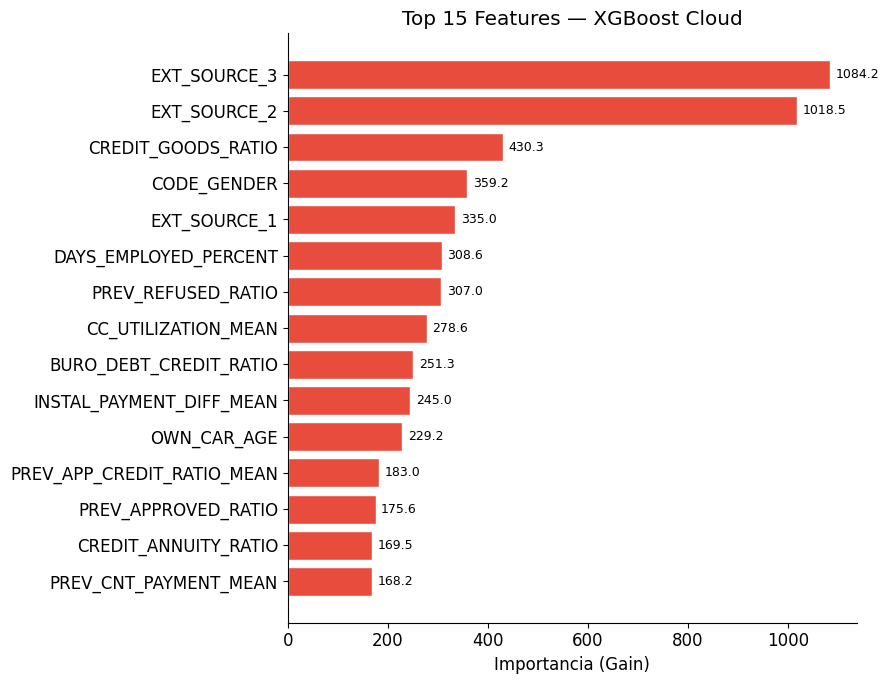

Feature importance guardada: /kaggle/working/feature_importance.png


,Feature,Gain
0,EXT_SOURCE_3,1084.178589
1,EXT_SOURCE_2,1018.520386
2,CREDIT_GOODS_RATIO,430.308838
3,CODE_GENDER,359.238892
4,EXT_SOURCE_1,334.998474
5,DAYS_EMPLOYED_PERCENT,308.551117
6,PREV_REFUSED_RATIO,307.048126
7,CC_UTILIZATION_MEAN,278.554443
8,BURO_DEBT_CREDIT_RATIO,251.250504
9,INSTAL_PAYMENT_DIFF_MEAN,245.000916


In [14]:
# ─── Feature importance (gain) ────────────────────────────────────────────────
importance_dict = xgb_final.get_score(importance_type='gain')
feat_imp_df     = pd.DataFrame(list(importance_dict.items()),
                               columns=['Feature', 'Gain'])
feat_imp_df     = feat_imp_df.sort_values('Gain', ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
top15   = feat_imp_df.head(15)
bars    = ax.barh(top15['Feature'][::-1], top15['Gain'][::-1],
                  color='#e74c3c', edgecolor='white')
ax.set_xlabel('Importancia (Gain)')
ax.set_title('Top 15 Features — XGBoost Cloud')

for bar, val in zip(bars, top15['Gain'][::-1]):
    ax.text(bar.get_width() + top15['Gain'].max()*0.01,
            bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(MODEL_DIR / 'feature_importance.png', dpi=120)
plt.show()
print(f'Feature importance guardada: {MODEL_DIR / "feature_importance.png"}')
display(feat_imp_df.reset_index(drop=True))

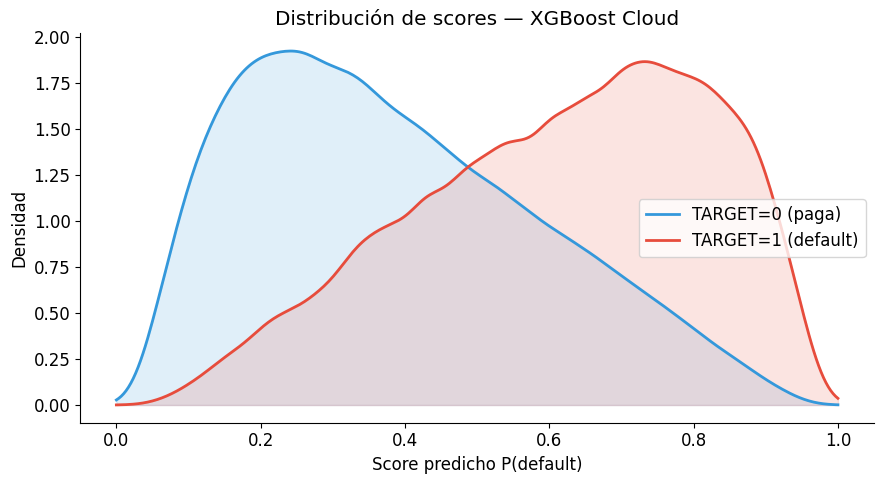

Distribución de scores guardada: /kaggle/working/score_distribution.png


In [15]:
# ─── Distribución de scores ───────────────────────────────────────────────────
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(9, 5))
for val, color, label in [(0, '#3498db', 'TARGET=0 (paga)'),
                           (1, '#e74c3c', 'TARGET=1 (default)')]:
    probs = y_prob_train[y == val]
    kde   = gaussian_kde(probs, bw_method=0.1)
    xs    = np.linspace(0, 1, 300)
    ax.plot(xs, kde(xs), color=color, lw=2, label=label)
    ax.fill_between(xs, kde(xs), alpha=0.15, color=color)

ax.set_xlabel('Score predicho P(default)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de scores — XGBoost Cloud')
ax.legend()
plt.tight_layout()
plt.savefig(MODEL_DIR / 'score_distribution.png', dpi=120)
plt.show()
print(f'Distribución de scores guardada: {MODEL_DIR / "score_distribution.png"}')

## 6. Guardar Modelo y Metadata

In [16]:
# ─── Guardar modelo ───────────────────────────────────────────────────────────
model_path = MODEL_DIR / 'xgboost_cloud_best.ubj'
xgb_final.save_model(model_path)

# ─── Guardar metadata para reproducibilidad y predicción local ────────────────
metadata = {
    'best_params'      : {k: float(v) if isinstance(v, (int, float)) else v
                          for k, v in best_p.items()},
    'best_n_rounds'    : int(best_n_rounds),
    'best_cv_auc'      : float(study_xgb.best_value),
    'train_auc'        : float(metrics['AUC']),
    'scale_pos_weight' : float(scale_pos_weight),
    'feature_cols'     : list(feature_cols),
    'n_trials'         : N_TRIALS,
    'n_folds'          : N_FOLDS,
    'early_stop'       : EARLY_STOP,
    'use_gpu'          : USE_GPU,
    'xgboost_version'  : xgb.__version__,
    'timestamp'        : pd.Timestamp.now().isoformat()
}

meta_path = MODEL_DIR / 'xgboost_cloud_metadata.json'
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print('=' * 65)
print('ARTEFACTOS GUARDADOS')
print('=' * 65)
print(f'  {model_path.name:<40} ({model_path.stat().st_size/1e6:.2f} MB)')
print(f'  {meta_path.name:<40}')
print(f'  optuna_trials.csv')
print(f'  optuna_history.png')
print(f'  roc_curve.png')
print(f'  learning_curve.png')
print(f'  feature_importance.png')
print(f'  score_distribution.png')
print('=' * 65)
print('\n>>> Descargar desde el Output tab de Kaggle:')
print(f'    - {model_path.name}')
print(f'    - {meta_path.name}')
print(f'    - optuna_trials.csv')
print('\n>>> Luego correr localmente: xgboost_cloud_predict.ipynb')

ARTEFACTOS GUARDADOS
  xgboost_cloud_best.ubj                   (0.90 MB)
  xgboost_cloud_metadata.json             
  optuna_trials.csv
  optuna_history.png
  roc_curve.png
  learning_curve.png
  feature_importance.png
  score_distribution.png

>>> Descargar desde el Output tab de Kaggle:
    - xgboost_cloud_best.ubj
    - xgboost_cloud_metadata.json
    - optuna_trials.csv

>>> Luego correr localmente: xgboost_cloud_predict.ipynb


## Resumen Final

In [17]:
# ─── Resumen ──────────────────────────────────────────────────────────────────
print('=' * 65)
print('XGBOOST CLOUD — RESUMEN')
print('=' * 65)
print('Hiperparámetros óptimos (Optuna):')
for k, v in best_p.items():
    print(f'  {k:<22}: {v}')
print(f'  {"n_estimators":<22}: {best_n_rounds}  (via early stopping)')
print('\nMétricas:')
print(f'  Train AUC       : {metrics["AUC"]}')
print(f'  CV AUC (Optuna) : {metrics["CV_AUC"]}')
print(f'  Gap Train - CV  : {metrics["AUC"] - metrics["CV_AUC"]:.5f}')
print(f'  Recall          : {metrics["Recall"]}')
print(f'  Precision       : {metrics["Precision"]}')
print(f'  F1              : {metrics["F1"]}')
print('\nEntorno:')
print(f'  XGBoost version : {xgb.__version__}')
print(f'  GPU usado       : {USE_GPU}')
print(f'  Timestamp       : {metadata["timestamp"]}')
print('=' * 65)

XGBOOST CLOUD — RESUMEN
Hiperparámetros óptimos (Optuna):
  max_depth             : 2
  learning_rate         : 0.05388108577817234
  subsample             : 0.5171942605576092
  colsample_bytree      : 0.954660201039391
  min_child_weight      : 3
  gamma                 : 3.31261142176991
  reg_alpha             : 6.388511557344611e-06
  reg_lambda            : 0.0004793052550782129
  n_estimators          : 998  (via early stopping)

Métricas:
  Train AUC       : 0.7854
  CV AUC (Optuna) : 0.76824
  Gap Train - CV  : 0.01716
  Recall          : 0.709
  Precision       : 0.1804
  F1              : 0.2876

Entorno:
  XGBoost version : 3.1.3
  GPU usado       : True
  Timestamp       : 2026-02-25T03:01:44.996031
